# Identificação NARX v2 (Melhores Práticas)
Neste notebook, aplicamos as melhorias discutidas para o modelo NARX:
1. Uso de múltiplos datasets de treino (iguais ao `node_v4.py`).
2. Redução das ordens `ny` e `nu` para capturar a dinâmica fundamental sem overfitting de ruído.
3. Arquitetura de rede mais compacta.
4. Concatenação adequada dos datasets.


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

# Seed para reprodutibilidade
rseed = 42
np.random.seed(rseed)
torch.manual_seed(rseed)
np.set_printoptions(precision=3)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## 1. Funções Auxiliares


In [22]:
def matReg(y, u, ny, nu):
    p = max(ny, nu) + 1
    (N, ) = y.shape
    (Nu, ) = u.shape

    if N != Nu:
        print('Dimensões inconsistentes')
        return (-1,-1)

    target = y[p-1:N]
    Phi = np.zeros((N-p+1, ny+nu))
    
    for i in range(ny):
        Phi[:, i] = y[p-i-2 : N-i-1]
    for i in range(nu):
        Phi[:, i+ny] = u[p-i-2 : N-i-1]

    return (target, Phi)

def freeRun(model, y, u, ny, nu, device):
    p = max(ny, nu) + 1
    (N, ) = y.shape

    yhat = np.zeros(N)
    yhat[:p-1] = y[:p-1] 

    for k in range(p, N+1):
        auxY = np.concatenate((yhat[(k-p):(k-1)], (0,)), axis=0)
        auxU = np.concatenate((u[(k-p):(k-1)], (0,)), axis=0)

        _, fr_input = matReg(auxY, auxU, ny, nu)
        
        tensor_input = torch.tensor(fr_input, dtype=torch.float32).to(device)
        yhat[k-1] = model.predict(tensor_input).item()
        
    return yhat[-(N-p+1):]


## 2. Carregamento e Preparação dos Múltiplos Datasets
Usamos os mesmos conjuntos de Treino e Validação do `node_v4.py`.
Também aplicamos o corte inicial/final para tirar os ruídos e a decimação por 2.


In [23]:
def carregar_experimento(url, decimacao=2, start_idx=1300, end_idx=-1600):
    df = pd.read_csv(url)
    df_sub = df.iloc[::decimacao].copy().reset_index(drop=True)
    
    if 'u_pct' in df_sub.columns:
        u_raw = df_sub['u_pct'].values
    else:
        u_raw = df_sub['motor_percent'].values
        
    y_raw = df_sub['angulo_deg'].values
    
    u = u_raw[start_idx:end_idx]
    y = y_raw[start_idx:end_idx]
    return u, y

BASE2 = "https://raw.githubusercontent.com/FelipeEduardoMarcondes/SYSTEM-IDENTIFICATION-AERO/main/experimentos/"

train_files = [
    "RODADA-2/multi-seno-1_0804_19-06.csv",
    "RODADA-2/seq-degraus-2_0804_19-38.csv",
    "RODADA-2/multi-seno-3_0804_19-44.csv",
    "RODADA-2/seq-degraus-1_0804_19-12.csv",
    "multi-seno-1_0807_16-57.csv",
    "multi-seno-2_0807_17-13.csv",
    "seq-degraus-1_0807_16-38.csv",
    "seq-degraus-aprbs-2_0807_17-23.csv",
    "seq-dragus-aprbs_0807_16-50.csv"
]

val_files = [
    "RODADA-2/chirp-1_0804_19-19.csv",
    "RODADA-2/multi-seno-2_0804_19-28.csv",
    "RODADA-2/seq-degraus-1_0804_19-09.csv",
]

scaler_u = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))
scaler_u.fit(np.array([[0], [100]]))
scaler_y.fit(np.array([[-180], [180]]))

print("Carregando e processando conjuntos de TREINO...")
u_train_list, y_train_list = [], []
for f in train_files:
    u, y = carregar_experimento(BASE2 + f, decimacao=2, start_idx=1500, end_idx=-1800)
    u_norm = scaler_u.transform(u.reshape(-1, 1)).flatten()
    y_norm = scaler_y.transform(y.reshape(-1, 1)).flatten()
    u_train_list.append(u_norm)
    y_train_list.append(y_norm)

print("Carregando e processando conjuntos de TESTE/VALIDAÇÃO...")
u_val_list, y_val_list = [], []
for f in val_files:
    u, y = carregar_experimento(BASE2 + f, decimacao=2, start_idx=1500, end_idx=-1800)
    u_norm = scaler_u.transform(u.reshape(-1, 1)).flatten()
    y_norm = scaler_y.transform(y.reshape(-1, 1)).flatten()
    u_val_list.append(u_norm)
    y_val_list.append(y_norm)


Carregando e processando conjuntos de TREINO...
Carregando e processando conjuntos de TESTE/VALIDAÇÃO...


## Visualização dos Conjuntos de Treino
Abaixo estão os gráficos da variável de saída (ângulo) para cada um dos 9 conjuntos de treinamento.


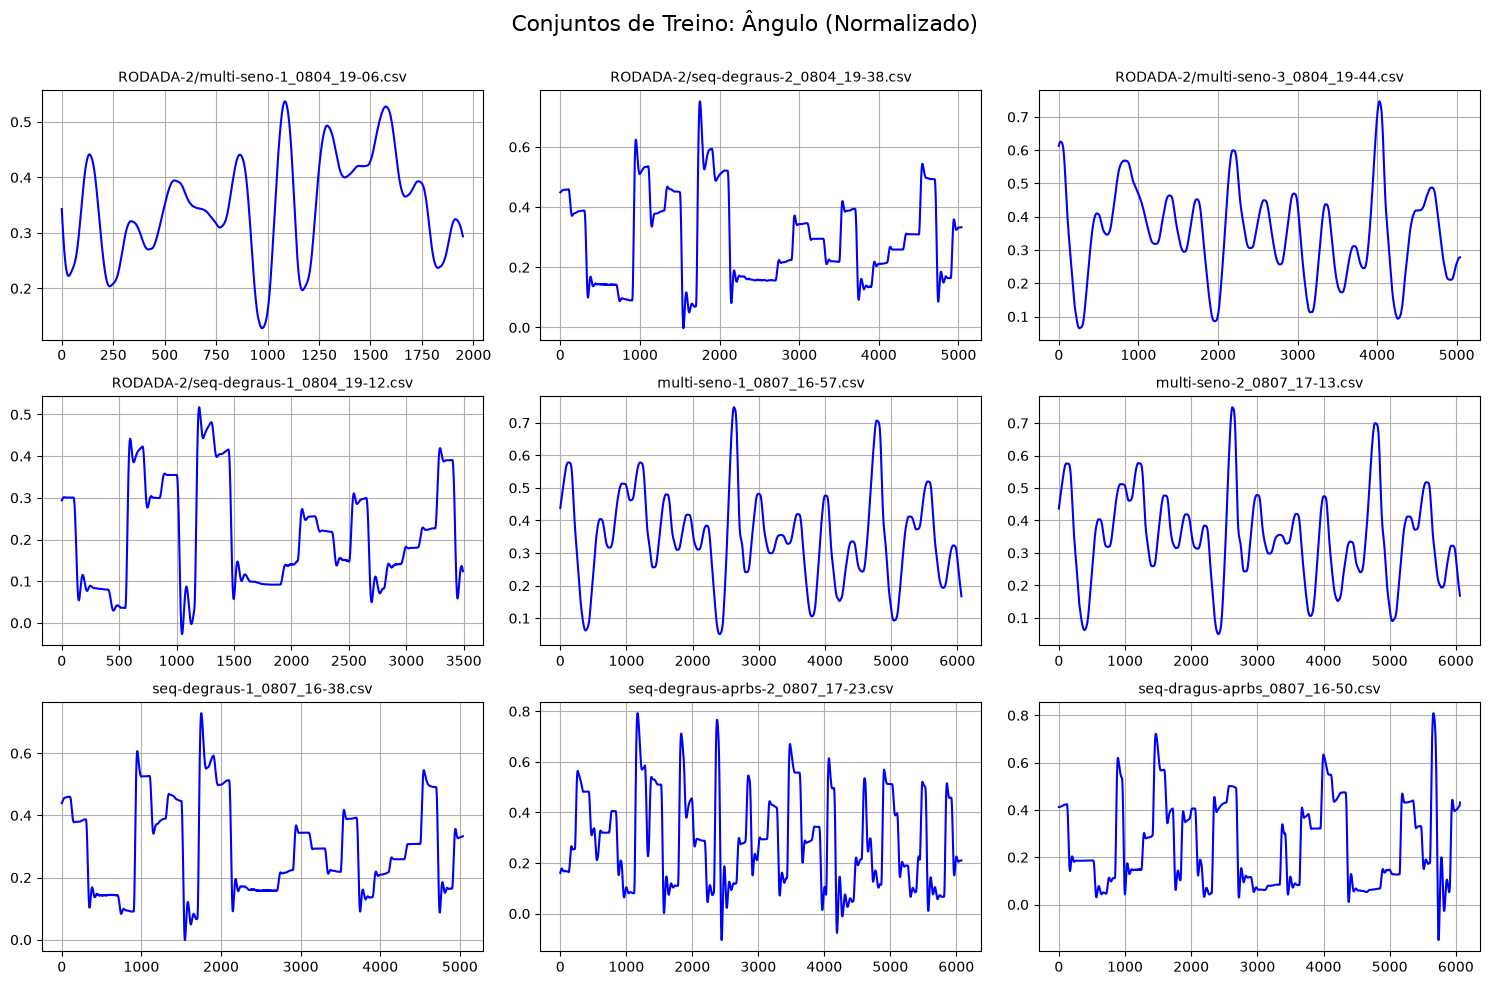

In [24]:
fig, axs = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Conjuntos de Treino: Ângulo (Normalizado)', fontsize=16)

for i, ax in enumerate(axs.flatten()):
    if i < len(y_train_list):
        ax.plot(y_train_list[i], color='blue')
        ax.set_title(train_files[i], fontsize=10)
        ax.grid(True)
    else:
        ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()


## 3. Matrizes de Regressão e Tensores
Geramos a matriz regressora separadamente para CADA dataset e depois as concatenamos.
Isto evita que o final de um experimento seja usado para prever o início do outro experimento.


In [25]:
# Reduzindo a ordem! 100 era overfitting demais.
ny = 30
nu = 30

Phie_all, Ye_all = [], []
for y_n, u_n in zip(y_train_list, u_train_list):
    (Y, Phi) = matReg(y_n, u_n, ny, nu)
    Ye_all.append(Y)
    Phie_all.append(Phi)

# Concatena todos os dados de treino
Ye_concat = np.concatenate(Ye_all, axis=0)
Phie_concat = np.concatenate(Phie_all, axis=0)

# O mesmo para validação (vamos apenas concatenar para fins de cálculo de loss rápido)
Yt_all, Phit_all = [], []
for y_n, u_n in zip(y_val_list, u_val_list):
    (Y, Phi) = matReg(y_n, u_n, ny, nu)
    Yt_all.append(Y)
    Phit_all.append(Phi)

Yt_concat = np.concatenate(Yt_all, axis=0)
Phit_concat = np.concatenate(Phit_all, axis=0)

Phie_t = torch.tensor(Phie_concat, dtype=torch.float32).to(device)
Ye_t   = torch.tensor(Ye_concat, dtype=torch.float32).view(-1, 1).to(device)

Phit_t = torch.tensor(Phit_concat, dtype=torch.float32).to(device)
Yt_t   = torch.tensor(Yt_concat, dtype=torch.float32).view(-1, 1).to(device)

# Noise Injection para ajudar no Free-Run
ruido = torch.randn_like(Phie_t[:, :ny]) * 0.05 
Phie_t[:, :ny] += ruido

dataset = TensorDataset(Phie_t, Ye_t)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)


## 4. Arquitetura da Rede e Treinamento


In [ ]:
class NARXModel(nn.Module):
    def __init__(self, ny, nu, hidden_dim1=64, hidden_dim2=32):
        super(NARXModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(ny + nu, hidden_dim1),
            nn.Tanh(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.Tanh(),
            nn.Linear(hidden_dim2, 1)
        )

    def forward(self, x):
        return self.net(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            return self.forward(x)

model = NARXModel(ny, nu, 64, 32).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)

epochs = 300
best_val_loss = float('inf')

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for inputs, targets in dataloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    epoch_loss /= len(dataloader)
    
    # Validação
    model.eval()
    with torch.no_grad():
        val_preds = model(Phit_t)
        val_loss = criterion(val_preds, Yt_t).item()
        
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_narx.pth')

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:3d}/{epochs} | Train Loss: {epoch_loss:.5f} | Val Loss: {val_loss:.5f}')

print("Treinamento finalizado! Carregando melhor modelo...")
model.load_state_dict(torch.load('best_narx.pth'))


Epoch   1/300 | Train Loss: 0.00143 | Val Loss: 0.00010
Epoch  10/300 | Train Loss: 0.00028 | Val Loss: 0.00015
Epoch  20/300 | Train Loss: 0.00024 | Val Loss: 0.00021
Epoch  30/300 | Train Loss: 0.00022 | Val Loss: 0.00017
Epoch  40/300 | Train Loss: 0.00021 | Val Loss: 0.00015
Epoch  50/300 | Train Loss: 0.00020 | Val Loss: 0.00016
Epoch  60/300 | Train Loss: 0.00020 | Val Loss: 0.00015
Epoch  70/300 | Train Loss: 0.00019 | Val Loss: 0.00016
Epoch  80/300 | Train Loss: 0.00019 | Val Loss: 0.00016
Epoch  90/300 | Train Loss: 0.00019 | Val Loss: 0.00016
Epoch 100/300 | Train Loss: 0.00019 | Val Loss: 0.00015
Epoch 110/300 | Train Loss: 0.00019 | Val Loss: 0.00015
Epoch 120/300 | Train Loss: 0.00019 | Val Loss: 0.00016
Epoch 130/300 | Train Loss: 0.00019 | Val Loss: 0.00016
Epoch 140/300 | Train Loss: 0.00019 | Val Loss: 0.00016
Epoch 150/300 | Train Loss: 0.00019 | Val Loss: 0.00016
Epoch 160/300 | Train Loss: 0.00019 | Val Loss: 0.00016
Epoch 170/300 | Train Loss: 0.00019 | Val Loss: 

<All keys matched successfully>

## 5. Avaliação Free-Run no conjunto de Validação


--- FREE-RUN NOS DATASETS DE TESTE ---
Dataset: RODADA-2/chirp-1_0804_19-19.csv
  R2: 0.7800 | RMSE: 9.64 graus


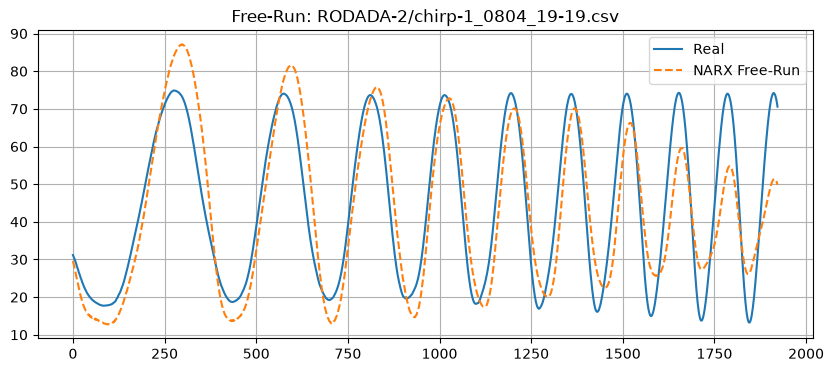

Dataset: RODADA-2/multi-seno-2_0804_19-28.csv
  R2: 0.7619 | RMSE: 11.33 graus


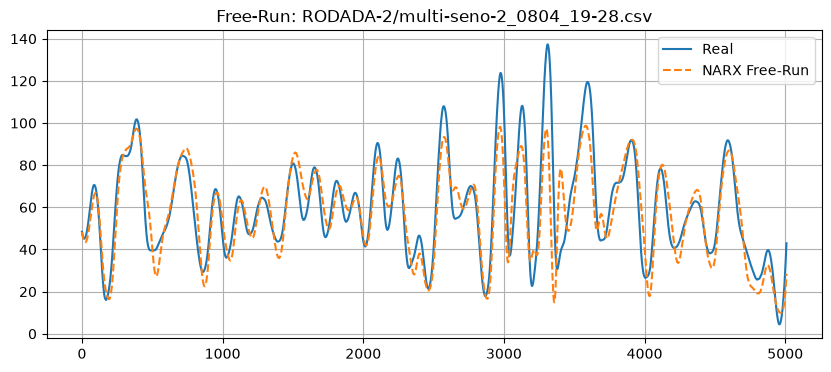

Dataset: RODADA-2/seq-degraus-1_0804_19-09.csv
  R2: 0.8309 | RMSE: 9.45 graus


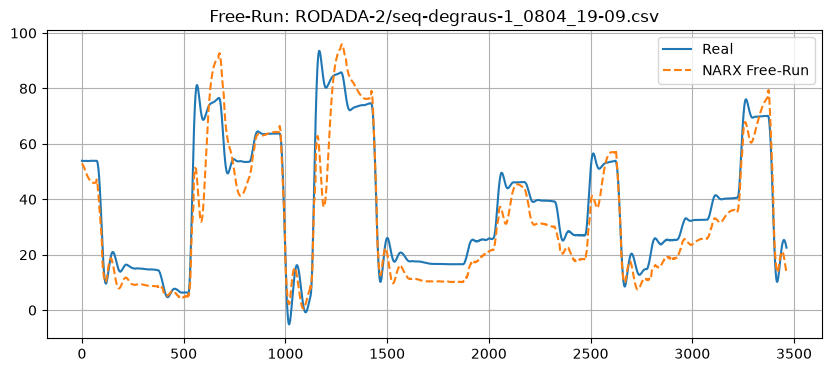

In [27]:
print("--- FREE-RUN NOS DATASETS DE TESTE ---")
rmse_list = []

for i, (y_n, u_n, file_name) in enumerate(zip(y_val_list, u_val_list, val_files)):
    y_test_pred0  = freeRun(model, y_n, u_n, ny, nu, device)
    
    y_real_original = scaler_y.inverse_transform(y_n.reshape(-1, 1)).flatten()
    y_pred_original = scaler_y.inverse_transform(y_test_pred0.reshape(-1, 1)).flatten()
    
    p = max(ny, nu) + 1
    # y_pred_original já vem sem as condições iniciais (tamanho N - p + 1)
    # Precisamos pegar exatamente a mesma janela do y_real
    y_real_eval = y_real_original[p-1:]
    y_pred_eval = y_pred_original
    
    r2 = r2_score(y_real_eval, y_pred_eval)
    rmse = np.sqrt(np.mean((y_real_eval - y_pred_eval)**2))
    
    print(f"Dataset: {file_name}")
    print(f"  R2: {r2:.4f} | RMSE: {rmse:.2f} graus")
    
    plt.figure(figsize=(10,4))
    plt.plot(y_real_eval, label='Real')
    plt.plot(y_pred_eval, label='NARX Free-Run', linestyle='dashed')
    plt.title(f'Free-Run: {file_name}')
    plt.legend()
    plt.grid()
    plt.show()
